In [12]:
from datetime import datetime, timedelta
from finpie.datasource.service import DataService
from mt5_backtest_runner import run_mt5_backtest
import glob
import os
import pandas as pd
from functools import reduce
import re
import math
from finpie.data.timeseries import TimeSeries
from finpie.data.multitimeseries import MultiTimeSeries
import numpy as np
import matplotlib.pyplot as plt
from finpie.analytics.genetic_portfolio_optimizer import GeneticPortfolioOptimizer, OptimizationConfig

In [14]:
data_path = r"C:\Users\enzob\AppData\Roaming\MetaQuotes\Terminal\Common\Files\backtests"
prod_path = r"C:\Users\enzob\AppData\Roaming\MetaQuotes\Terminal\Common\Files\prod"

In [15]:
csv_files = glob.glob(os.path.join(data_path, "*.csv"))

backtest_map = {}
stats_map = {}

i = 0
for file in csv_files:
    try: 
        if i % 1000 == 0:
            print(i)
        strategy_key = file.split('\\')[-1].split('.')[0]
        df = pd.read_csv(file, sep='\t', decimal=',', encoding='UTF-16LE')
        df[strategy_key] = df['PnL'].astype(float)
        if len(df) > 250 and df.sum()[strategy_key] > 0:
            df = df[['Date', strategy_key]]
            df['Date'] = pd.to_datetime(df['Date'])
            df[strategy_key] = df[strategy_key].cumsum()

            backtest_map[strategy_key] = TimeSeries(df.set_index('Date'))
        i = i + 1
    except Exception as e:
        print(f"Error processing {strategy_key}: {e}")


0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
20000
21000
22000
23000
24000
25000
26000
27000
28000
29000
30000
31000
32000
33000
34000
35000
36000
37000
38000
39000
40000
41000
42000
43000
44000
45000
46000
47000
48000
49000
50000
51000
52000
53000
54000
55000
56000
57000
58000
59000
60000
61000
62000
63000
64000
65000
66000
67000
68000
69000
70000
71000
72000
73000
74000
75000
76000
77000
78000
79000
80000
81000
82000
83000
84000
85000
86000
87000
88000
89000
90000
91000
92000
93000
94000
95000
96000
97000
98000
99000
100000
101000
102000
103000
104000
105000
106000
107000
108000
109000
110000
111000
112000
113000
114000
115000
116000
117000
118000
119000
120000
121000
122000
123000
124000
125000
126000
127000
128000
129000
130000
131000
132000
133000
134000
135000
136000
137000
138000
139000
140000
141000
142000
143000
144000
145000
146000
147000
148000
149000
150000
151000
152000
153000
154000
155000
156000


In [16]:
stats_map = {}
i = 0
for backtest in backtest_map.keys():
    if i % 1000 == 0:
        print(i)
    stats_map[backtest] = {
        'strategy': backtest,
        'sharpe_ratio': backtest_map[backtest].sharpe_ratio(method='absolute').iloc[0],
        'max_drawdown': backtest_map[backtest].max_drawdown(percentage=False).iloc[0],
        'pnl': backtest_map[backtest].data.iloc[-1].iloc[0]
    }
    i = i + 1

0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
20000
21000
22000
23000
24000
25000
26000
27000
28000
29000
30000
31000
32000
33000
34000
35000
36000
37000
38000
39000
40000
41000
42000
43000
44000
45000
46000
47000
48000
49000
50000
51000
52000
53000
54000
55000
56000
57000
58000
59000
60000
61000
62000
63000
64000
65000
66000
67000
68000
69000
70000
71000
72000
73000
74000
75000
76000
77000
78000
79000
80000
81000
82000
83000
84000
85000
86000
87000
88000
89000
90000
91000
92000
93000
94000
95000
96000
97000
98000
99000
100000
101000
102000
103000
104000
105000
106000
107000
108000
109000
110000
111000
112000
113000
114000
115000
116000
117000
118000
119000
120000
121000
122000
123000
124000
125000
126000
127000
128000
129000
130000
131000
132000
133000
134000
135000
136000
137000
138000
139000
140000
141000
142000
143000
144000
145000
146000
147000
148000
149000
150000


In [13]:
stats_df = pd.DataFrame(stats_map.values())
stats_df['risk_adjusted_score'] = stats_df['pnl'] / abs(stats_df['max_drawdown'] + 0.01)

risk_adjusted_score_threshold = 4
sharpe_ratio_threshold = 1.1
max_drawdown_threshold = -15_000
pnl_threshold = 40_000

filtered_stats_df = stats_df[(stats_df['risk_adjusted_score'] >= risk_adjusted_score_threshold) & 
        (stats_df['sharpe_ratio'] >= sharpe_ratio_threshold) & 
        (stats_df['max_drawdown'] >= max_drawdown_threshold) & 
        (stats_df['pnl'] >= pnl_threshold)].reset_index(drop = True).copy()

filtered_stats_df['score'] = filtered_stats_df['risk_adjusted_score'] * filtered_stats_df['sharpe_ratio']
filtered_stats_df = filtered_stats_df.sort_values('score', ascending = False).reset_index(drop = True)

top_strategies = filtered_stats_df['strategy'].tolist()

In [16]:
stats_df.sort_values('pnl')

,strategy,sharpe_ratio,max_drawdown,pnl,risk_adjusted_score
49963,WIN$N_WIN$N_MOMENTUM_MAMA_DISTANCE_SPREAD_1429...,0.003239,-28653.0,1.0,0.000035
23519,WIN$N_WDO$N_MAMA_DISTANCE_MAMA_DISTANCE_SPREAD...,-0.003892,-11373.0,1.0,0.000088
83768,WIN$N_WIN$N_PRICES_RETURNS_RATIO_1802512179059...,-0.020322,-36384.0,1.0,0.000027
34405,WIN$N_WDO$N_PRICE_MAMA_DISTANCE_PRICE_MAMA_DIS...,-0.012658,-3125.0,1.0,0.000320
7814,WIN$N_BOVA11_PRICES_PRICES_RATIO_1809012204833...,0.005843,-13450.0,1.0,0.000074
...,...,...,...,...,...
71858,WIN$N_WIN$N_PRICES_MOMENTUM_RATIO_589136555328...,1.547679,-13745.0,95031.0,6.913865
67911,WIN$N_WIN$N_PRICES_MOMENTUM_RATIO_102181730317...,1.414041,-13235.0,95036.0,7.180663
25308,WIN$N_WDO$N_MAMA_DISTANCE_MAMA_DISTANCE_SPREAD...,1.583653,-15112.0,95300.0,6.306251
71291,WIN$N_WIN$N_PRICES_MOMENTUM_RATIO_404754090781...,1.454313,-11505.0,95968.0,8.341424


In [ ]:
mts = MultiTimeSeries([backtest_map[key] for key in backtest_map])

In [7]:
mts = MultiTimeSeries([backtest_map[strategy] for strategy in top_strategies])

In [8]:
# Check if the last 20 values are the same for each column
staled_strategies = []

for column in mts.data.columns:
    last_20_values = mts.data[column].tail(20)
    # Check if all values in the last 20 are the same
    if last_20_values.nunique() == 1:
        staled_strategies.append(column)

staled_strategies

[]

In [9]:
mts.data.to_parquet('mts2.parquet')

In [3]:
mts = MultiTimeSeries(pd.read_parquet('mts2.parquet'))

In [4]:
mts_is, mts_os = mts.slice(0.5)

<Axes: xlabel='Date'>

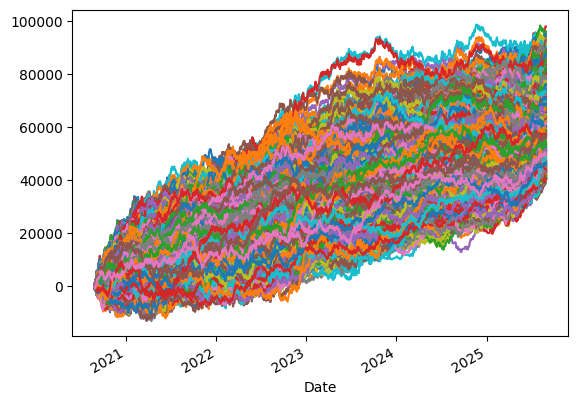

In [10]:
mts.data.plot(legend = False)

In [3]:
def custom_fitness_score(self, timeseries: TimeSeries) -> float:
    return timeseries.value(-1)[0] * (-15_000 / timeseries.max_drawdown(percentage = False)[0])

In [4]:
config = OptimizationConfig(
    weight_mode="binary",
    population_size=500,           # Number of individuals in population
    max_generations=1000,          # Maximum number of generations  
    max_strategies=10,             # Maximum strategies per portfolio
    elite_size=10,                 # Number of best individuals to preserve
    tournament_size=5,             # Tournament selection size
    crossover_rate=0.8,           # Probability of crossover
    mutation_rate=0.1,            # Probability of mutation
    early_stopping_patience=100,   # Stop if no improvement for N generations
    convergence_threshold=1e-6,   # Minimum improvement threshold
    random_seed=np.random.randint(1, 1000000), # For reproducible results
    mass_extinction_events=20,     # Number of extinction events to trigger
    extinction_percentage=0.5,     # Percentage of population to kill (0.0 to 1.0)
    protect_elite_from_extinction=True,  # Whether elite individuals are protected from extinction
    fitness_score_function=custom_fitness_score
)

In [7]:
optimizer = GeneticPortfolioOptimizer(mts, config)
best_individual, history = optimizer.optimize()

Starting genetic optimization...
Population size: 500
Max generations: 1000
Available strategies: 18177


c:\Users\enzob\OneDrive\Desktop\ai\finpie\venv\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\enzob\AppData\Local\Temp\ipykernel_15208\1263845453.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return timeseries.value(-1)[0] * (-15_000 / timeseries.max_drawdown(percentage = False)[0])
c:\Users\enzob\OneDrive\Desktop\ai\finpie\venv\Lib\site-packages\numpy\_core\_methods.py:52: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


Generation 0: Best fitness: 524358.16, Avg fitness: 239400.59, Best PnL: 613534.00, Best strategies: 10
Generation 1: Best fitness: 592919.00, Avg fitness: 326210.00, Best PnL: 486075.00, Best strategies: 8
Generation 2: Best fitness: 680553.35, Avg fitness: 384706.00, Best PnL: 515315.00, Best strategies: 9
Generation 3: Best fitness: 694022.46, Avg fitness: 436474.86, Best PnL: 525375.00, Best strategies: 9
Generation 4: Best fitness: 842405.27, Avg fitness: 479626.52, Best PnL: 646181.00, Best strategies: 10
Generation 5: Best fitness: 852045.76, Avg fitness: 505700.42, Best PnL: 633070.00, Best strategies: 10
Generation 6: Best fitness: 868388.23, Avg fitness: 532155.19, Best PnL: 636297.00, Best strategies: 10
Generation 7: Best fitness: 868388.23, Avg fitness: 541521.06, Best PnL: 636297.00, Best strategies: 10
Generation 8: Best fitness: 902182.72, Avg fitness: 543162.93, Best PnL: 617514.00, Best strategies: 10
Generation 9: Best fitness: 1027599.73, Avg fitness: 558357.60, Bes

C:\Users\enzob\OneDrive\Desktop\ai\finpie\finpie\data\timeseries.py:134: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns_df = self.data.pct_change()
C:\Users\enzob\AppData\Local\Temp\ipykernel_15208\1263845453.py:2: RuntimeWarning: divide by zero encountered in scalar divide
  return timeseries.value(-1)[0] * (-15_000 / timeseries.max_drawdown(percentage = False)[0])
C:\Users\enzob\AppData\Local\Temp\ipykernel_15208\1263845453.py:2: RuntimeWarning: invalid value encountered in scalar multiply
  return timeseries.value(-1)[0] * (-15_000 / timeseries.max_drawdown(percentage = False)[0])


Generation 60: Best fitness: 1177800.99, Avg fitness: nan, Best PnL: 663259.00, Best strategies: 10
Generation 70: Best fitness: 1270598.14, Avg fitness: 594758.41, Best PnL: 664184.00, Best strategies: 10
Generation 80: Best fitness: 1270598.14, Avg fitness: 601995.68, Best PnL: 664184.00, Best strategies: 10
Generation 90: Best fitness: 1270598.14, Avg fitness: 633434.62, Best PnL: 664184.00, Best strategies: 10
Generation 100: Best fitness: 1270598.14, Avg fitness: 592912.50, Best PnL: 664184.00, Best strategies: 10
Generation 110: Best fitness: 1270598.14, Avg fitness: 592648.81, Best PnL: 664184.00, Best strategies: 10
Generation 120: Best fitness: 1270598.14, Avg fitness: 603051.12, Best PnL: 664184.00, Best strategies: 10
Generation 130: Best fitness: 1270598.14, Avg fitness: 592856.27, Best PnL: 664184.00, Best strategies: 10
Generation 140: Best fitness: 1270598.14, Avg fitness: 593571.35, Best PnL: 664184.00, Best strategies: 10
Generation 150: Best fitness: 1270598.14, Avg f

In [3]:
print("🏆 OPTIMIZATION RESULTS")
print("="*50)
print(f"✅ Best strategies: {best_individual.strategies}")
print(f"📊 Number of strategies: {len(best_individual.strategies)}")
print(f"💰 Best PnL: {best_individual.fitness_metrics.pnl:,.2f}")
print(f"📉 Max Drawdown: {best_individual.fitness_metrics.max_drawdown:,.2f}")
print(f"📈 Sharpe Ratio: {best_individual.fitness_metrics.sharpe_ratio:.4f}")
print(f"⭐ Fitness Score: {best_individual.fitness_metrics.fitness_score:,.2f}")


🏆 OPTIMIZATION RESULTS


NameError: name 'best_individual' is not defined

In [9]:
weights = best_individual.get_weights()
print(f"\n🎯 Portfolio Weights:")
for strategy, weight in weights.items():
    print(f"   {strategy}: {weight}")
print(f"📊 Total weight sum: {sum(weights.values())}")


🎯 Portfolio Weights:
   WIN$N_BOVA11_RETURNS_RETURNS_SPREAD_12564443784359430336: 1.0
   WIN$N_WDO$N_PRICE_MAMA_DISTANCE_PRICE_MAMA_DISTANCE_SPREAD_7328996469416558308: 1.0
   WIN$N_WIN$N_MAMA_DISTANCE_PRICES_SINGLE_5333410912102830065: 1.0
   WIN$N_WIN$N_MOMENTUM_PRICE_MAMA_DISTANCE_SPREAD_4270428073669901408: 1.0
   WIN$N_WIN$N_PRICES_MAMA_DISTANCE_SPREAD_10558340005255846357: 1.0
   WIN$N_WIN$N_PRICES_RETURNS_RATIO_5201379658369764814: 1.0
   WIN$N_WIN$N_RETURNS_PRICE_MAMA_DISTANCE_SPREAD_7733437387756533535: 1.0
   WIN$N_WIN$N_RETURNS_PRICE_MAMA_DISTANCE_SPREAD_9963263065696529: 1.0
   WIN$N_WSP$N_PRICE_MAMA_DISTANCE_PRICE_MAMA_DISTANCE_SPREAD_15415494267593554024: 1.0
   WIN$N_WSP$N_RSI_RSI_RATIO_2133870432529020215: 1.0
📊 Total weight sum: 10.0


In [3]:
weights = {
    "WIN$N_BOVA11_RETURNS_RETURNS_SPREAD_12564443784359430336": 1.0,
    "WIN$N_WDO$N_PRICE_MAMA_DISTANCE_PRICE_MAMA_DISTANCE_SPREAD_7328996469416558308": 1.0,
    "WIN$N_WIN$N_MAMA_DISTANCE_PRICES_SINGLE_5333410912102830065": 1.0,
    "WIN$N_WIN$N_MOMENTUM_PRICE_MAMA_DISTANCE_SPREAD_4270428073669901408": 1.0,
    "WIN$N_WIN$N_PRICES_MAMA_DISTANCE_SPREAD_10558340005255846357": 1.0,
    "WIN$N_WIN$N_PRICES_RETURNS_RATIO_5201379658369764814": 1.0,
    "WIN$N_WIN$N_RETURNS_PRICE_MAMA_DISTANCE_SPREAD_7733437387756533535": 1.0,
    "WIN$N_WIN$N_RETURNS_PRICE_MAMA_DISTANCE_SPREAD_9963263065696529": 1.0,
    "WIN$N_WSP$N_PRICE_MAMA_DISTANCE_PRICE_MAMA_DISTANCE_SPREAD_15415494267593554024": 1.0,
    "WIN$N_WSP$N_RSI_RSI_RATIO_2133870432529020215": 1.0
}

In [3]:
weights = {'WIN$N_WIN$N_MAMA_DISTANCE_PRICES_SINGLE_4740326949518766729': 2,
'WIN$N_WIN$N_MAMA_DISTANCE_PRICES_SINGLE_12531247915380950771': 2,  
'WIN$N_WIN$N_MAMA_DISTANCE_PRICES_SINGLE_16373282826601042165': 2,
'WIN$N_WIN$N_MOMENTUM_PRICES_SINGLE_2860728670216838373': 2,
'WIN$N_WIN$N_MAMA_DISTANCE_PRICES_SINGLE_14404137727714950776': 2,  
'WIN$N_WIN$N_MAMA_DISTANCE_PRICES_SINGLE_5825986493472449226': 2,
'WIN$N_WIN$N_MOMENTUM_PRICES_SINGLE_4239346232884195296': 2,
'WIN$N_WIN$N_MOMENTUM_PRICES_SINGLE_6459620599795782076': 2,  
'WIN$N_WIN$N_MOMENTUM_PRICES_SINGLE_7590629248183035233': 2,
'WIN$N_WIN$N_MOMENTUM_PRICES_SINGLE_17883194500393558434': 2,
'WIN$N_WIN$N_MOMENTUM_PRICES_SINGLE_17944400443684480011': 2,
'WIN$N_WIN$N_MOMENTUM_PRICES_SINGLE_18139625452937142447': 2,
'WIN$N_WIN$N_PRICES_MOMENTUM_RATIO_7120646003864724257': 2,
'WIN$N_WIN$N_PRICES_PRICES_SINGLE_10452268042522536927': 2,
'WIN$N_WIN$N_RETURNS_PRICES_SINGLE_16173509637117411615': 2,
'WIN$N_WIN$N_RETURNS_PRICES_SINGLE_4143951337554611639': 2,
'WIN$N_WSP$N_PRICES_PRICES_RATIO_15058096088782341321': 2,
'WIN$N_WSP$N_RETURNS_RETURNS_RATIO_5402585817166700934': 2,
'WIN$N_WSP$N_RETURNS_RETURNS_RATIO_17677861672037907476': 2,
'WIN$N_WIN$N_RSI_PRICES_SINGLE_6142762435996739789': 2}

<Axes: xlabel='Date'>

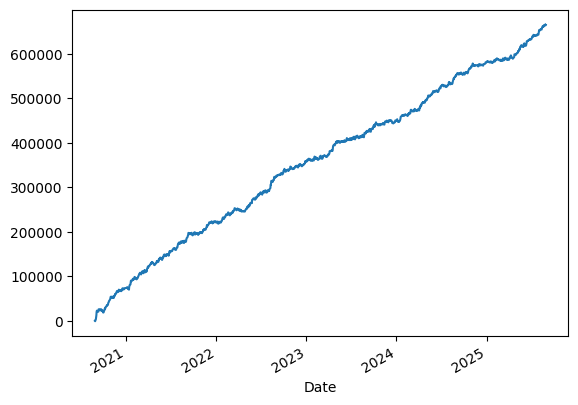

In [4]:
best_portfolio = mts.portfolio(weights=weights, shares = True, percentage = False)
(best_portfolio.data).plot(legend=False)

<Axes: xlabel='Date'>

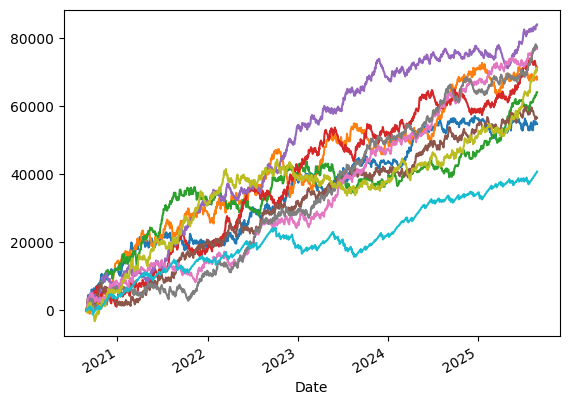

In [5]:
(mts.data[weights.keys()]).plot(legend=False)

In [6]:
best_portfolio.max_drawdown(percentage = False)[0]

C:\Users\enzob\AppData\Local\Temp\ipykernel_12776\557645687.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  best_portfolio.max_drawdown(percentage = False)[0]


np.float64(-7617.0)

In [9]:
simulated_portfolios = best_portfolio.generate_bootraped_timeseries(simulations = 50, method = 'absolute')
simulated_mts = MultiTimeSeries(simulated_portfolios)
simulated_mts.max_drawdown(percentage = False).describe(percentiles = [0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

count       50.000000
mean    -18961.460000
std       5541.418997
min     -38431.000000
1%      -35984.430000
5%      -30005.050000
10%     -25478.400000
25%     -21790.750000
50%     -17387.500000
75%     -14852.250000
90%     -13739.100000
95%     -13075.800000
99%     -12181.510000
max     -11937.000000
dtype: float64

In [13]:
simulated_mts.max_drawdown(percentage = False).describe(percentiles = [0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).to_dict()

{'count': 50.0,
 'mean': -18961.46,
 'std': 5541.418996824491,
 'min': -38431.0,
 '1%': -35984.43,
 '5%': -30005.05,
 '10%': -25478.4,
 '25%': -21790.75,
 '50%': -17387.5,
 '75%': -14852.25,
 '90%': -13739.1,
 '95%': -13075.800000000001,
 '99%': -12181.51,
 'max': -11937.0}

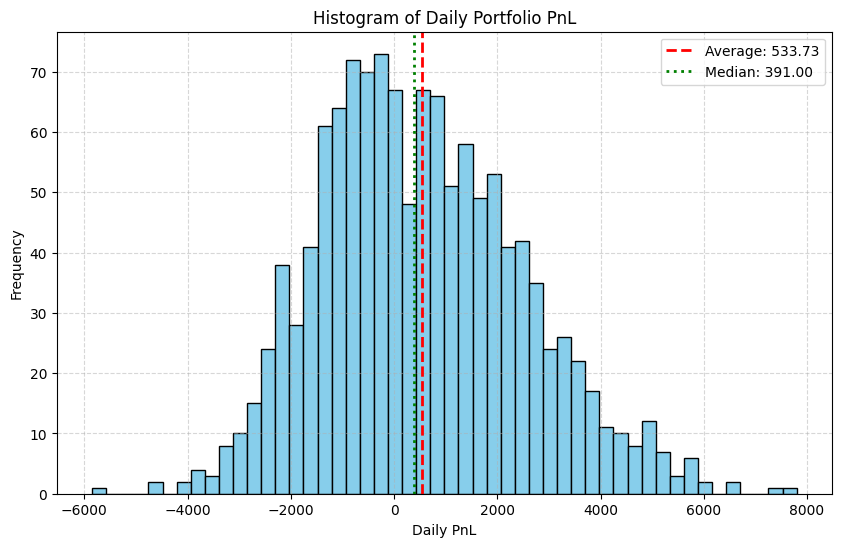

In [8]:
import matplotlib.pyplot as plt

# Plot histogram of daily portfolio PnL (diff) with average and median lines
pnl_diff = best_portfolio.data.diff().dropna()
plt.figure(figsize=(10,6))
plt.hist(pnl_diff.values, bins=50, color='skyblue', edgecolor='black')

# Calculate average and median
avg_pnl = pnl_diff.values.mean()
median_pnl = np.median(pnl_diff.values)

# Plot average and median lines
plt.axvline(avg_pnl, color='red', linestyle='dashed', linewidth=2, label=f'Average: {avg_pnl:.2f}')
plt.axvline(median_pnl, color='green', linestyle='dotted', linewidth=2, label=f'Median: {median_pnl:.2f}')

plt.title("Histogram of Daily Portfolio PnL")
plt.xlabel("Daily PnL")
plt.ylabel("Frequency")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

In [ ]:
N = 100  # Number of random shuffles
shuffled_timeseries_dd = []

for i in range(N):
    shuffled = np.random.permutation(pnl_diff.portfolio)
    shuffled = shuffled.cumsum()
    ts = TimeSeries(
        pd.DataFrame({'values': shuffled}, index=pnl_diff.index), 
        metadata=None  # or provide appropriate metadata if needed
    )
    shuffled_timeseries_dd.append(ts.max_drawdown(percentage = False)['values'])
pd.Series(shuffled_timeseries_dd).describe(percentiles = [0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

count      100.000000
mean    -15624.610000
std       3532.544497
min     -28372.000000
1%      -28160.140000
5%      -21926.800000
10%     -20112.600000
25%     -17044.250000
50%     -15163.500000
75%     -13249.250000
90%     -12112.100000
95%     -11531.250000
99%     -10261.610000
max     -10025.000000
dtype: float64

In [26]:
ts.max_drawdown(percentage = False)['pnl']

np.float64(-16054.0)

In [ ]:
mts.max_drawdown(percentage = False)

pnl       -21270.0
pnl_0     -10466.0
pnl_1     -18008.0
pnl_2     -17295.0
pnl_3     -20591.0
            ...   
pnl_994   -19856.0
pnl_995   -19791.0
pnl_996   -17768.0
pnl_997   -17025.0
pnl_998   -12639.0
Length: 1000, dtype: float64

<Axes: xlabel='Date'>

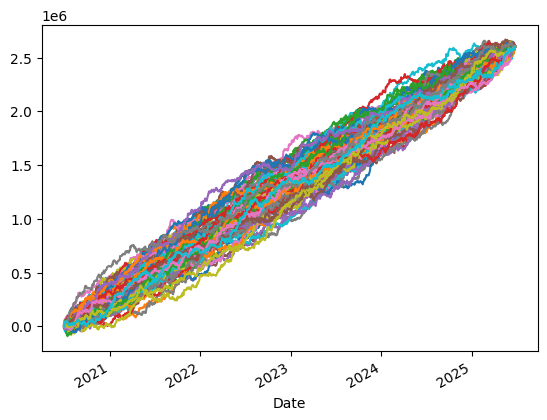

In [18]:
mts.data.plot(legend = False)

In [22]:
# Calculate how many days have PnL less than -18,000
num_days_pnl_below_18000 = (pnl_diff.values < -18_000).sum()
total_days = len(pnl_diff)
frequency = num_days_pnl_below_18000 / total_days

print(f"Number of days with PnL < -18,000: {num_days_pnl_below_18000}")
print(f"Total days: {total_days}")
print(f"Frequency: {frequency:.4%} of days")


Number of days with PnL < -18,000: 13
Total days: 1239
Frequency: 1.0492% of days


In [14]:
best_portfolio.skewness(method='absolute')

portfolio    1.209152
dtype: float64

In [114]:
population_history_summary = optimizer.get_population_history_summary()
print(f"\n📋 Top 5 generations:")
display(population_history_summary.sort_values(by='best_fitness', ascending=False).head(5))


📋 Top 5 generations:


,generation,best_fitness,avg_fitness,worst_fitness,best_pnl,avg_pnl,avg_strategies,diversity,population_size
2023,2041,733874.0,360437.662,0.0,733874.0,475653.444,6.824,431,500
2251,2271,733874.0,351972.460,0.0,733874.0,454732.606,6.416,425,500
2260,2280,733874.0,364903.478,0.0,733874.0,450933.302,6.430,448,500
2278,2298,733874.0,357827.522,0.0,733874.0,449803.988,6.376,445,500
2277,2297,733874.0,375338.632,0.0,733874.0,442791.420,6.248,431,500


In [115]:
cache = optimizer.get_cache_values().sort_values(by='fitness_score', ascending=False).head(5)

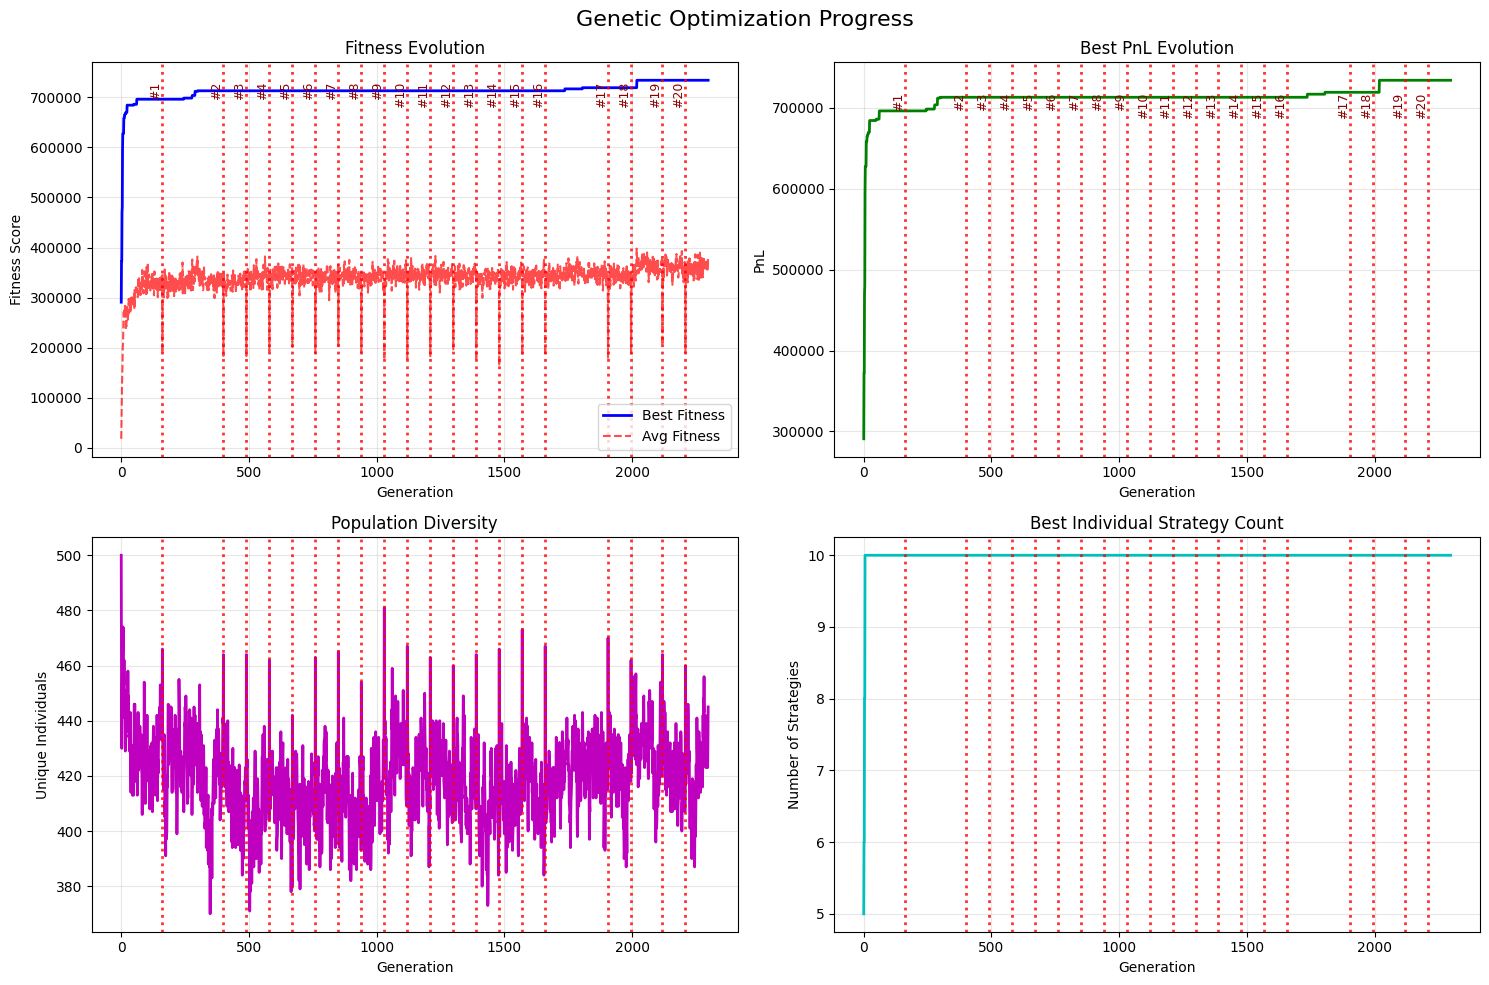


EXTINCTION EVENTS SUMMARY:
   Total events: 20
   Occurred at generations: [160, 399, 489, 579, 669, 759, 849, 939, 1029, 1119, 1209, 1299, 1389, 1479, 1569, 1659, 1905, 1995, 2118, 2208]
   Kill percentage: 50.0%
   Elite protection: True


In [116]:
optimizer.plot_optimization_history()

In [118]:
# 9. Convergence analysis
print(f"\n📈 Convergence Analysis:")
print(f"   Generations run: {len(history)}")
print(f"   Final diversity: {history.iloc[-1]['population_diversity']}")
print(f"   Improvement over time: {history['best_fitness'].iloc[-1] - history['best_fitness'].iloc[0]:,.2f}")


📈 Convergence Analysis:
   Generations run: 2299
   Final diversity: 445
   Improvement over time: 442,891.00


In [120]:
for key in weights.keys():
    import shutil
    import os

    # Get the source and destination paths
    source_path = os.path.join(data_path, '..', 'parameters', f'{key}.set')
    dest_path = os.path.join(data_path, '..', 'prod')

    # Create destination directory if it doesn't exist
    os.makedirs(dest_path, exist_ok=True)

    # Copy the file
    try:
        shutil.copy2(source_path, dest_path)
        print(f"✅ Copied {key}.set to prod directory")
    except FileNotFoundError:
        print(f"❌ File {key}.set not found in parameters directory")
    except Exception as e:
        print(f"❌ Error copying {key}.set: {e}")

✅ Copied WIN$N_WIN$N_MAMA_DISTANCE_PRICES_SINGLE_3710890210617043809.set to prod directory
✅ Copied WIN$N_WIN$N_MAMA_DISTANCE_PRICES_SINGLE_9182433471824319715.set to prod directory
✅ Copied WIN$N_WIN$N_MOMENTUM_PRICES_SINGLE_11324207794435635012.set to prod directory
✅ Copied WIN$N_WIN$N_MOMENTUM_PRICES_SINGLE_13780232369952555023.set to prod directory
✅ Copied WIN$N_WIN$N_MOMENTUM_PRICES_SINGLE_14889073697660784894.set to prod directory
✅ Copied WIN$N_WIN$N_MOMENTUM_PRICES_SINGLE_2316223254540482715.set to prod directory
✅ Copied WIN$N_WIN$N_MOMENTUM_PRICES_SINGLE_905780126640470498.set to prod directory
✅ Copied WIN$N_WIN$N_PRICES_PRICES_SINGLE_16946273351945078559.set to prod directory
✅ Copied WIN$N_WIN$N_PRICES_RSI_RATIO_9809414258768190489.set to prod directory
✅ Copied WIN$N_WSP$N_PRICES_PRICES_RATIO_10030793964830540977.set to prod directory


In [11]:
import os
import glob

# Get all files in the prod directory
prod_files = glob.glob(os.path.join(prod_path, '*'))

for file in prod_files:
    run_mt5_backtest(
        expert_name='sino\\ZScoreStrategy',
        expert_params_file=f"sino\\prod\\{file.split('\\')[-1]}",
        symbol="WIN$N",
        start_date="2020.01.01",
        end_date="2025.12.31",
        timeframe="M1",
        model=2
    )

In [12]:
backtest_map = {}
for file in prod_files:
    backtest_file = file.split("\\")[-1].replace('set', 'csv')
    strategy_key = file.split("\\")[-1].replace('set', '')
    backtest_file = os.path.join(data_path, backtest_file)
    df = pd.read_csv(backtest_file, sep='\t', decimal=',', encoding='UTF-16LE')
    df[strategy_key] = df['PnL'].astype(float)
    df = df[['Date', strategy_key]]
    df['Date'] = pd.to_datetime(df['Date'])
    df[strategy_key] = df[strategy_key].cumsum()

    backtest_map[strategy_key] = TimeSeries(df.set_index('Date'))
    

In [13]:
mts = MultiTimeSeries(list(backtest_map.values()))

In [14]:
for key in backtest_map.keys():
    print(backtest_map[key].data.index.max())

2025-08-01 00:00:00
2025-08-01 00:00:00
2025-08-01 00:00:00
2025-08-01 00:00:00
2025-08-01 00:00:00
2025-08-01 00:00:00
2025-08-01 00:00:00
2025-08-01 00:00:00
2025-08-01 00:00:00
2025-08-01 00:00:00


In [15]:
weights = {}
for key in backtest_map.keys():
    weights[key] = 1

In [ ]:
weights = {}
for key in backtest_map.keys():
    weights[key] = 1
portfolio = mts.portfolio(weights=weights, shares = True, percentage = False)

In [71]:
curr_ts = TimeSeries(portfolio.data[(portfolio.data.index >= '2025-06-30') & (portfolio.data.index <= '2025-07-31')])

In [ ]:
curr_ts.data.diff()

,values
Date,
2025-06-30,NaN
2025-07-01,-348.0
2025-07-02,-82.0
2025-07-03,-13.0
2025-07-04,121.0
2025-07-07,5680.0
2025-07-08,971.0
2025-07-09,-816.0
2025-07-10,-1550.0


In [104]:
curr_ts.max_drawdown(percentage = False)

values   -6130.0
dtype: float64

In [17]:
import MetaTrader5 as mt5
from datetime import datetime
import pandas as pd
pd.set_option('display.max_columns', 500) # number of columns to be displayed
pd.set_option('display.width', 1500)      # max table width to display
# display data on the MetaTrader 5 package
print("MetaTrader5 package author: ",mt5.__author__)
print("MetaTrader5 package version: ",mt5.__version__)
print()
# establish connection to the MetaTrader 5 terminal
if not mt5.initialize():
    print("initialize() failed, error code =",mt5.last_error())
    quit()
 
# get the number of deals in history
from_date = datetime(2025,7,1)
to_date = datetime(2025,9,2)
# get deals for symbols whose names contain "GBP" within a specified interval
deals = mt5.history_deals_get(from_date, to_date, group="*WIN*")

MetaTrader5 package author:  MetaQuotes Ltd.
MetaTrader5 package version:  5.0.4993



In [52]:
fills['financial_volume'] = fills['volume'] * fills['price'] * 0.2

In [ ]:
(fills['profit'].sum() / (fills['financial_volume'].sum() / 2) * 10_000) * 140000

np.float64(53.212062618764776)

In [18]:
fills = pd.DataFrame(list(deals),columns=deals[0]._asdict().keys())

In [19]:
fills.time = pd.to_datetime(fills.time, unit='s')

In [40]:
pnl_ts = TimeSeries(fills.groupby(fills['time'].dt.date).agg({'profit': 'sum'}).cumsum())

In [41]:
pnl_ts.sharpe_ratio(method='absolute')

profit    3.196241
dtype: float64

In [42]:
pnl_ts.volatility(method='absolute') / 1000

profit    75.791586
dtype: float64

In [57]:
pnl_ts.data

,profit
time,
2025-07-01,-266.0
2025-07-02,-409.0
2025-07-03,-466.0
2025-07-04,-318.0
2025-07-07,5348.0
2025-07-08,5903.0
2025-07-09,4349.0
2025-07-10,2771.0
2025-07-11,2062.0


In [44]:
pnl_returns = pnl_ts.returns(method = 'absolute')

In [80]:
scale_df = pnl_returns.data
scale_df['scale'] = np.where(scale_df.index > '2025-08-01', 2, 1)
scale_df['scale'] = np.where(scale_df.index > '2025-08-20', 3, scale_df['scale'])

In [81]:
pnl_returns.data['scaled'] = pnl_returns.data['profit'] / pnl_returns.data['scale']

In [83]:
pnl_returns.data['scaled'] = pnl_returns.data['scaled'] / 1000 + (0.05547647074929352026471809363)

In [82]:
0.05547647074929352026471809363 * 1000

55.476470749293526

<Axes: xlabel='time'>

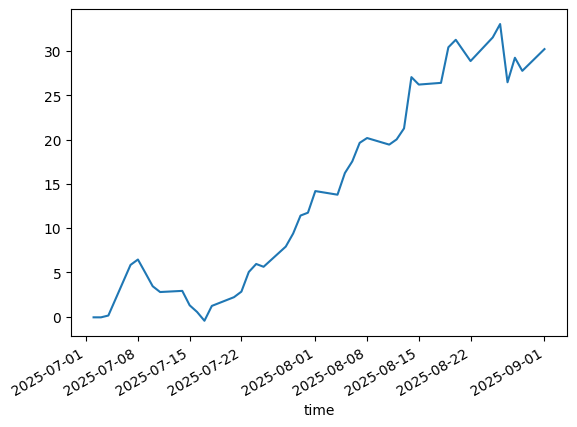

In [84]:
pnl_returns.data['scaled'].cumsum().plot()

In [27]:
pnl_ts.returns(method = 'absolute').data

,profit
time,
2025-07-01,NaN
2025-07-02,-143.0
2025-07-03,-57.0
2025-07-04,148.0
2025-07-07,5666.0
2025-07-08,555.0
2025-07-09,-1554.0
2025-07-10,-1578.0
2025-07-11,-709.0


In [11]:
mts.slice(0.5)

(MultiTimeSeries(symbols=',,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,